# Proyecto 2
## Random Forest

##### Importación de librerías.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

##### Importación de datos.

In [2]:
df = pd.read_csv('DB_LIMPIA.csv', delimiter=';', index_col = 0)
df.head(2)

,VIC_SEXO,VIC_EDAD,TOTAL_HIJOS,VIC_ESCOLARIDAD,VIC_EST_CIV,VIC_GRUPET,VIC_TRABAJA,VIC_DISC,VIC_REL_AGR,OTRAS_VICTIMAS,...,HEC_TIPAGRE,INST_DONDE_DENUNCIO,AGR_SEXO,AGR_EDAD,AGR_ESCOLARIDAD,AGR_EST_CIV,AGR_GRUPET,AGR_TRABAJA,INST_DENUN_HECHO,MEDIDAS_SEGURIDAD
0,Mujeres,11,-1,Primaria,Desconocido,Ladino,No,Desconocido,Hijos(as),-1,...,Física-sexual,NaN,Hombres,58,Primaria,Soltero,Ladino,No,Ministerio Público,Desconocido
1,Hombres,4,-1,Desconocido,Desconocido,Ladino,Desconocido,No,Hijos(as),2,...,Física-psicológica,NaN,Mujeres,27,Primaria,Soltero,Ladino,Si,Procuraduría de los Derechos Humanos,Desconocido


##### Tipos de datos y faltantes.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 358998 entries, 0 to 31897
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   VIC_SEXO             358998 non-null  object
 1   VIC_EDAD             358998 non-null  int64 
 2   TOTAL_HIJOS          358998 non-null  int64 
 3   VIC_ESCOLARIDAD      358998 non-null  object
 4   VIC_EST_CIV          358998 non-null  object
 5   VIC_GRUPET           358998 non-null  object
 6   VIC_TRABAJA          358998 non-null  object
 7   VIC_DISC             358998 non-null  object
 8   VIC_REL_AGR          358998 non-null  object
 9   OTRAS_VICTIMAS       358998 non-null  int64 
 10  HEC_DIA              358998 non-null  int64 
 11  HEC_MES              358998 non-null  object
 12  HEC_ANO              358998 non-null  int64 
 13  HEC_AREA             358998 non-null  object
 14  HEC_TIPAGRE          358998 non-null  object
 15  INST_DONDE_DENUNCIO  44229 non-null   ob

##### Se crean los DataFrame de víctimas y agresores con el fin de crear etiquetas y unificarlos.

In [4]:
# Se crea el DataFrame de víctimas.
df_victimas = df.loc[:, ['VIC_SEXO', 'VIC_EDAD', 'VIC_ESCOLARIDAD', 'VIC_EST_CIV', 'VIC_GRUPET', 'VIC_TRABAJA']]
df_victimas.columns = ['SEXO', 'EDAD', 'ESCOLARIDAD', 'ESTADO_CIVIL', 'GRUPO_ETNICO', 'TRABAJA']
df_victimas['ETIQUETA'] = 'VICTIMA'

# Se crea el DataFrame de agresores.
df_agresores = df.loc[:, ['AGR_SEXO', 'AGR_EDAD', 'AGR_ESCOLARIDAD', 'AGR_EST_CIV', 'AGR_GRUPET', 'AGR_TRABAJA']]
df_agresores.columns = ['SEXO', 'EDAD', 'ESCOLARIDAD', 'ESTADO_CIVIL', 'GRUPO_ETNICO', 'TRABAJA']
df_agresores['ETIQUETA'] = 'AGRESOR'

# Se crea el DataFrame de cluster.
df_modelo = pd.concat([df_victimas, df_agresores])
df_modelo.head(5)

,SEXO,EDAD,ESCOLARIDAD,ESTADO_CIVIL,GRUPO_ETNICO,TRABAJA,ETIQUETA
0,Mujeres,11,Primaria,Desconocido,Ladino,No,VICTIMA
1,Hombres,4,Desconocido,Desconocido,Ladino,Desconocido,VICTIMA
2,Hombres,11,Primaria,Desconocido,Ladino,No,VICTIMA
3,Mujeres,6,Desconocido,Desconocido,Ladino,Desconocido,VICTIMA
4,Hombres,11,Primaria,Desconocido,Ladino,No,VICTIMA


##### Muestra de los datos.

In [5]:
df_modelo = df_modelo.sample(frac=0.40, random_state=0)

##### Tipos de datos y faltantes.

In [6]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 287198 entries, 16683 to 10266
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   SEXO          287198 non-null  object
 1   EDAD          287198 non-null  int64 
 2   ESCOLARIDAD   287198 non-null  object
 3   ESTADO_CIVIL  287198 non-null  object
 4   GRUPO_ETNICO  287198 non-null  object
 5   TRABAJA       287198 non-null  object
 6   ETIQUETA      287198 non-null  object
dtypes: int64(1), object(6)
memory usage: 17.5+ MB


##### Separación de etiqueta.

In [7]:
X = df_modelo.drop(columns = ['ETIQUETA'])
y = df_modelo['ETIQUETA']

##### Get Dummies.

In [8]:
X = pd.get_dummies(X, drop_first=True)

##### Separación de datos.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

##### Rejilla de Hiperparámetros.

In [10]:
#param_grid = {
#    "n_estimators": [50, 75, 100],
#    "max_depth": [None, 3, 5, 7],
#    "min_samples_split": [2, 5, 7],
#    "min_samples_leaf": [1, 2, 4],
#    "max_features": ["sqrt", "log2"],
#    "criterion": ["gini", "entropy"]
#}

param_grid = {
    "n_estimators": [75],
    "max_depth": [None],
    "min_samples_split": [2],
    "min_samples_leaf": [4],
    "max_features": ["sqrt"],
    "criterion": ["gini"]
}

##### Definición del modelo.

In [11]:
rf_model = RandomForestClassifier(random_state=0, n_jobs=-1)

##### Definición del Grid Search y validación cruzada.

In [12]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

##### Entrenamiento del modelo.

In [13]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini'], 'max_depth': [None], 'max_features': ['sqrt'], 'min_samples_leaf': [4], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

##### Mejor modelo.

In [14]:
best_model = grid_search.best_estimator_

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

print("\nMejor accuracy en validación cruzada:")
print(grid_search.best_score_)

Mejores hiperparámetros encontrados:
{'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 75}

Mejor accuracy en validación cruzada:
0.8899581310014197


##### Predicción del modelo.

In [15]:
y_pred = best_model.predict(X_test)

##### Métricas del modelo.

In [16]:
print(classification_report(y_test, y_pred, target_names=y.unique()))

              precision    recall  f1-score   support

     VICTIMA       0.90      0.88      0.89     28802
     AGRESOR       0.88      0.91      0.89     28638

    accuracy                           0.89     57440
   macro avg       0.89      0.89      0.89     57440
weighted avg       0.89      0.89      0.89     57440



##### Matriz de confusión.

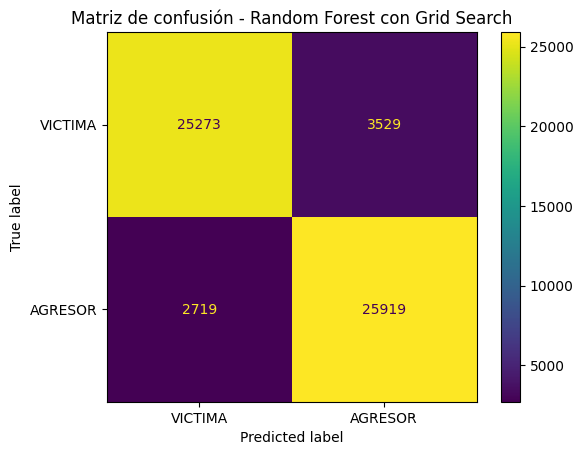

In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=y.unique()
)
disp.plot()
plt.title("Matriz de confusión - Random Forest con Grid Search")
plt.show()

##### Accuracy del conjunto de entrenamiento.

In [18]:
y_pred_train = best_model.predict(X_train)
print(classification_report(y_train, y_pred_train, target_names=y.unique()))

              precision    recall  f1-score   support

     VICTIMA       0.91      0.88      0.89    115206
     AGRESOR       0.88      0.91      0.89    114552

    accuracy                           0.89    229758
   macro avg       0.89      0.89      0.89    229758
weighted avg       0.89      0.89      0.89    229758



##### Matriz de confusión entrenamiento.

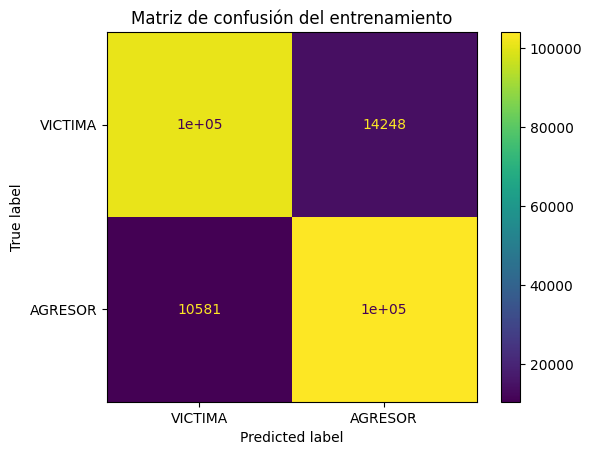

In [20]:
cm = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=y.unique()
)
disp.plot()
plt.title('Matriz de confusión del entrenamiento')
plt.show()